In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, names=columns)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [2]:
# df['Gender'] = df['Gender'].replace({'Female': -1, 'Male': 1})
# df['Online Classes Taken'] = df['Online Classes Taken'].replace({True: 1, False: -1})
# df['ParentalSupport'] = df['ParentalSupport'].replace({"High": 1, "Medium": 0, "Low": -1})
# df = df.drop(['StudentID', 'Name'], axis=1)
# df['GOTAWAY'] = df['FinalGrade'].apply(lambda x: 1 if x >= 80 else -1)
# df = df.drop(['FinalGrade'], axis=1)
# X = df.drop(['GOTAWAY'], axis=1)
# y = df['GOTAWAY']



In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
import pandas as pd
import jinja2
C=len(df.columns)
L=len(df.index)
CN=df.count() #количество
NP=((L-CN)/L)*100 #процент пропущенных значений
MN=df.min() #минимум
Q1=df.quantile(q=0.25) #первый квартиль
MA=df.mean() #среднее значение
ME=df.median() #медиана
Q3=df.quantile(q=0.75) #третий квартиль
MX=df.max() #максимум
ST=df.std() #стандартное отклонение
P=df.nunique() #мощность
IQ=Q3-Q1 #интерквартильный размах
frame = pd.concat([CN, NP, MN, Q1, MA, ME, Q3, MX, ST, P, IQ], axis=1, join="inner")
frame=frame.T
f=pd.DataFrame(frame)
f.index=['Количество', 'Процент пропусков', 'Минимум', 'Первый квартиль','Среднее', 'Медиана', 'Третий квартиль', 'Максимум','Стандартное отклонение', 'Мощность', 'Интерквартильный размах']
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
f1=f.style.apply(lambda x: ["background-color:tomato" if i==1 else "" for i in x], axis=1, subset=(["Мощность"], slice(None))).apply(lambda x: ["background-color:tomato" if i>=60 else "" for i in x], axis=1, subset=(["Процент пропусков"], slice(None))).apply(lambda x: ["background-color:steelblue" if (i<30 and i>0) else "" for i in x], axis=1, subset=(["Процент пропусков"], slice(None))).apply(lambda x: ["background-color:limegreen" if i==0 else "" for i in x], axis=1, subset=(["Процент пропусков"], slice(None)))
f1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Количество,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
Процент пропусков,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Минимум,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
Первый квартиль,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
Среднее,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
Медиана,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
Третий квартиль,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
Максимум,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000
Стандартное отклонение,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
Мощность,17.000000,136.000000,47.000000,51.000000,186.000000,248.000000,517.000000,52.000000,2.000000


<Axes: >

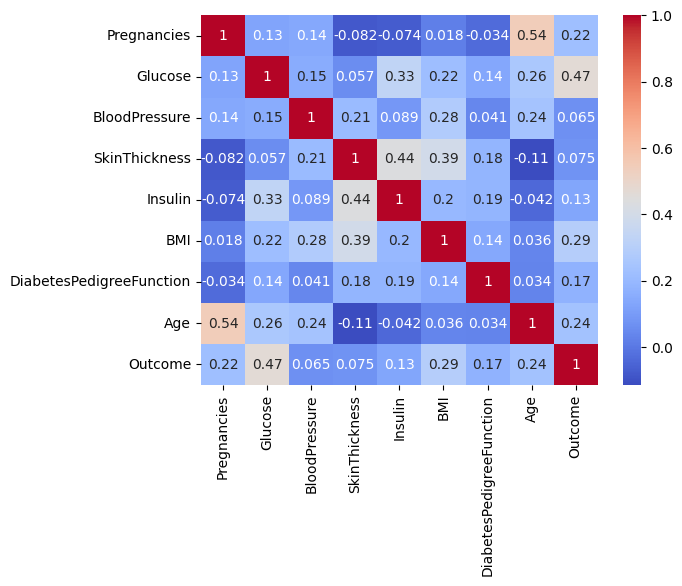

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [7]:
df['Outcome'] = df['Outcome'].replace({0: -1, 1: 1})
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

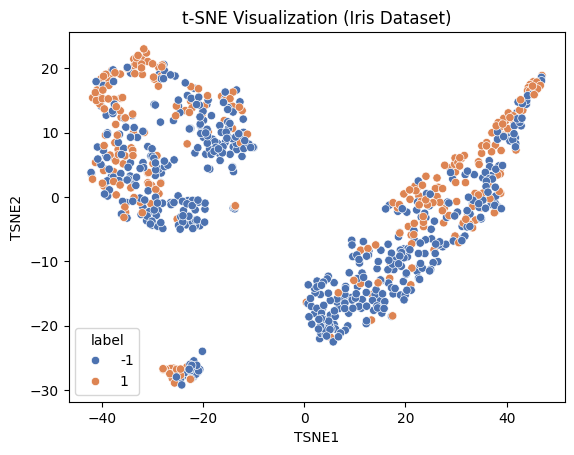

In [8]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X.dropna(inplace=True)  # Ensure there are no NaN values
y = y[X.index]  # Align y with the cleaned X
X_embedded = tsne.fit_transform(X)

# Put results into a DataFrame for plotting
df2 = pd.DataFrame({
    'TSNE1': X_embedded[:, 0],
    'TSNE2': X_embedded[:, 1],
    'label': y
})

# Plot with Seaborn
sns.scatterplot(data=df2, x='TSNE1', y='TSNE2', hue='label', palette='deep')
plt.title("t-SNE Visualization (Iris Dataset)")
plt.show()

In [36]:
class Momentum():
    def __init__(self, gamma=0.9):
        self.gamma = gamma
        self.v = None

    def update(self, weights, grad, learning_rate):
        # grad — это уже np.ndarray
        if self.v is None:
            self.v = np.zeros_like(weights)
        self.v = self.gamma * self.v + (1 - self.gamma) * grad(weights)
        return weights - learning_rate * self.v

In [ ]:
from optimizer.nesterov import Nesterov
from loss.LogLoss import LogLoss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
y[y == 0] = -1  
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
y_train

X_train
y_train


Outcome
-1    500
 1    268
Name: count, dtype: int64


357    1
73    -1
352   -1
497   -1
145   -1
514   -1
291    1
132    1
559   -1
631   -1
719    1
395   -1
41    -1
637   -1
108   -1
481   -1
56     1
323    1
685   -1
758   -1
572   -1
529   -1
24     1
465   -1
247   -1
443    1
351   -1
327   -1
110    1
82    -1
51    -1
449   -1
762   -1
703   -1
619    1
198    1
538   -1
329   -1
302   -1
334   -1
139   -1
485    1
547   -1
18    -1
593   -1
140   -1
326    1
266    1
626   -1
83    -1
61     1
632   -1
735   -1
29    -1
335   -1
599   -1
557   -1
311   -1
429    1
182   -1
586    1
679   -1
464   -1
223   -1
393   -1
766    1
570   -1
671   -1
412   -1
755    1
176   -1
525   -1
333   -1
163   -1
248   -1
682   -1
74    -1
439   -1
643   -1
104   -1
114    1
749    1
92    -1
380   -1
89    -1
417    1
477   -1
713   -1
707   -1
506    1
11     1
43     1
42    -1
167   -1
675    1
666    1
381   -1
178   -1
705   -1
518   -1
177    1
532   -1
539    1
257   -1
616   -1
440    1
15     1
478   -1
256   -1
388    1
360    1
3

In [42]:

class SGDClassifier2:
    def __init__(self, learning_rate=0.01, alpha=0.0001, n_iterations=1000, optimizer=Momentum(), loss=LogLoss(), weight_init='random', penalty=None, lambd=0.5, ordering = 'random'):
        self.learning_rate = learning_rate
        self.alpha=alpha
        self.n_iterations = n_iterations
        self.optimizer = optimizer
        self.weight_init = weight_init 
        self.loss = loss
        self.penalty = penalty
        self.Q = 0
        self.lambd = lambd
        self.ordering = ordering
        self.losses=[]
        np.random.seed(42)
        
    def _initialize_weights(self, n_features, y = None, X = None):
        match self.weight_init:
            case 'random':
                self.weights = (1/(n_features))*np.random.random_sample(n_features) - 1/(2*n_features)
            case 'correlation':
                self.weights = np.array([np.dot(X[:,i],y)/np.dot(X[:,i], X[:,i]) for i in range(n_features)])
            case "multi":
                a = [SGDClassifier2(learning_rate=self.learning_rate, alpha=self.alpha, n_iterations=5, optimizer=self.optimizer, loss=self.loss, weight_init='random', penalty=self.penalty) for _ in range(10)]
                _=[i.fit(X,y) for i in a]
                best = min(a, key=lambda model: model.Q)
                self.weights = best.weights



    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._initialize_weights(n_features, y, X)

        
        self.Q = self.loss.loss(y * (np.dot(X, self.weights))).mean()
        shuffle_indices=np.random.permutation(n_samples)


        for iter in range(self.n_iterations):
            shuffle_indices=np.random.permutation(n_samples)
            match self.ordering:
                case 'random':
                    shuffle_indices = np.random.permutation(n_samples)
                case "margin-first":
                    margin = y * (np.dot(X, self.weights))
                    shuffle_indices = (margin).argsort()
            

            for _x,_y in zip(X[shuffle_indices], y[shuffle_indices]):
                match self.penalty:
                    case 'l2':
                        updated_weights=self.optimizer.update(self.weights-self.learning_rate*self.alpha*self.weight, lambda w: self.loss.derivative(_y * (np.dot(_x, w))) * _y * _x +self.alpha*w, self.learning_rate)
                    
                        self.weights = updated_weights
                    case None:
                        updated_weights = self.optimizer.update(self.weights, lambda w: self.loss.derivative(_y * (np.dot(_x, w))) * _y * _x , self.learning_rate)

                        self.weights = updated_weights
                    case _:
                        raise ValueError("penalty must be 'l2' or None")
                loss = self.loss.loss(y * (np.dot(X, self.weights))).mean()
                
                updated_q =self.lambd*self.loss.loss(_y * (np.dot(_x, self.weights)))+(1-self.lambd)*self.Q
               
                self.Q = updated_q
        
            self.losses.append(loss)
            print(iter)
            print(f"Loss after ${iter}, ${loss}")        

    def predict(self, X):
        linear_model = np.dot(X, self.weights)
        return np.where(linear_model >= 0, 1, -1)
          


0
Loss after $0, $1.2599708180209848
1
Loss after $1, $1.385532726513289
2
Loss after $2, $1.3515323581511622
3
Loss after $3, $1.347205644110871
4
Loss after $4, $1.2988927969885213
5
Loss after $5, $1.2559758319230767
6
Loss after $6, $1.2076817046774713
7
Loss after $7, $1.1894441360706387
8
Loss after $8, $1.1853974632674964
9
Loss after $9, $1.1771343686145121
10
Loss after $10, $1.1750968090624538
11
Loss after $11, $1.1698415478021162
12
Loss after $12, $1.1613793309693614
13
Loss after $13, $1.1498309279800847
14
Loss after $14, $1.1473260644474754
15
Loss after $15, $1.143873076115981
16
Loss after $16, $1.142826055796829
17
Loss after $17, $1.1421052822818254
18
Loss after $18, $1.1411497370888237
19
Loss after $19, $1.14078491023143
20
Loss after $20, $1.140315200110064
21
Loss after $21, $1.1388244468238904
22
Loss after $22, $1.1383416757348617
23
Loss after $23, $1.1369555711860864
24
Loss after $24, $1.1383109781618372
25
Loss after $25, $1.136967679171442
26
Loss after 

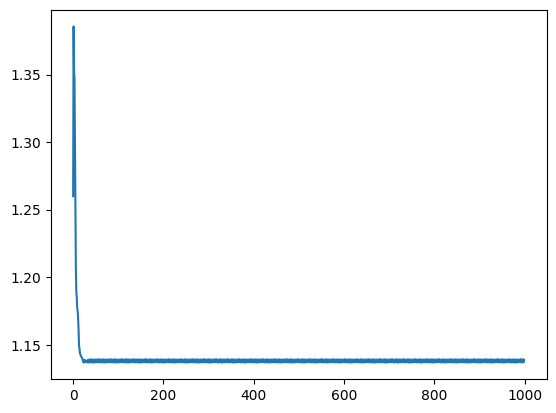

In [43]:
from optimizer.nesterov import Nesterov
from optimizer.sgd import SgdOptimizer
a = SGDClassifier2(learning_rate=0.1, n_iterations=1000, optimizer=Momentum(), loss=LogLoss(), weight_init='random', penalty=None, ordering ="margin-first", lambd=0.5)

a.fit(X_train, y_train.to_numpy())

result =a.predict(X_test)
TP=0
FN=0
FP=0
TN=0
for i in range(len(result)):
    if result[i]==1 and y_test.to_numpy()[i]==1:
        TP+=1
    elif result[i]==1 and y_test.to_numpy()[i]==-1:
        FP+=1
    elif result[i]==-1 and y_test.to_numpy()[i]==1:
        FN+=1
    elif result[i]==-1 and y_test.to_numpy()[i]==-1:
        TN+=1
accuracy=(TP+TN)/(TP+TN+FP+FN)
print("Accuracy:", accuracy)

confusion_matrix = np.array([[TP, FP], [FN, TN]])
print("Confusion Matrix:\n", confusion_matrix)

print(a.losses)
plt.plot(a.losses)


In [12]:
from sklearn.linear_model import SGDClassifier


clf = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.01, max_iter=1000, random_state=42, penalty="l2")
clf.fit(X_train, y_train)
result_sklearn = clf.predict(X_test)




In [13]:
result =a.predict(X_test)


In [14]:
result = result_sklearn

In [15]:
TP=0
FN=0
FP=0
TN=0
for i in range(len(result)):
    if result[i]==1 and y_test.to_numpy()[i]==1:
        TP+=1
    elif result[i]==1 and y_test.to_numpy()[i]==-1:
        FP+=1
    elif result[i]==-1 and y_test.to_numpy()[i]==1:
        FN+=1
    elif result[i]==-1 and y_test.to_numpy()[i]==-1:
        TN+=1
accuracy=(TP+TN)/(TP+TN+FP+FN)
print("Accuracy:", accuracy)
confusion_matrix = np.array([[TP, FP], [FN, TN]])
print("Confusion Matrix:\n", confusion_matrix)


Accuracy: 0.7239583333333334
Confusion Matrix:
 [[43 27]
 [26 96]]


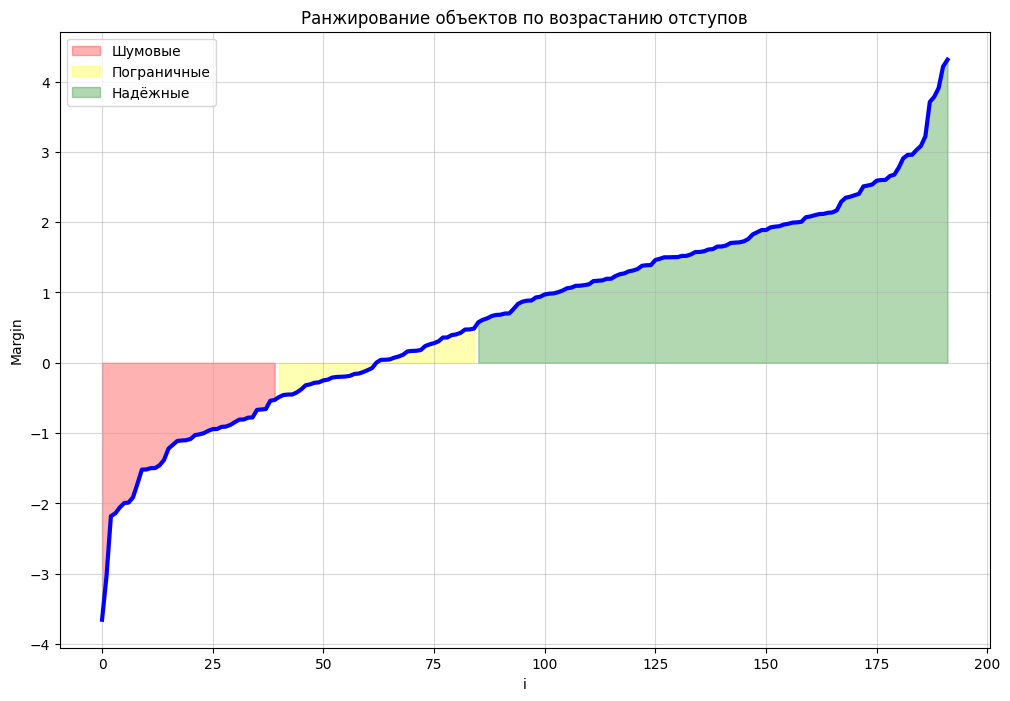

In [16]:
margins = y_test * (X_test @ a.weights)
margins=margins.to_numpy()
sorted_margins = margins[np.argsort(margins)]

plt.figure(figsize=(12, 8))
plt.plot(range(len(sorted_margins)), sorted_margins, 'b-', linewidth=3)

n_points = len(sorted_margins)
x_range = np.arange(n_points)

threshold = 0.5
noisy = sorted_margins < -threshold  
borderline = (sorted_margins >= -threshold) & (sorted_margins <= threshold)
reliable = sorted_margins > threshold
plt.fill_between(x_range[noisy], sorted_margins[noisy], 0, 
                     color='red', alpha=0.3, label='Шумовые')
plt.fill_between(x_range[borderline], sorted_margins[borderline], 0, 
                     color='yellow', alpha=0.3, label='Пограничные')
plt.fill_between(x_range[reliable], sorted_margins[reliable], 0, 
                     color='green', alpha=0.3, label='Надёжные') 


plt.xlabel('i')
plt.ylabel('Margin')
plt.title('Ранжирование объектов по возрастанию отступов')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()